## World Bank WDI Data Viz Example

In this example we take data from the [World Bank's World Development Indicators](https://databank.worldbank.org/source/world-development-indicators) and plot it to show the capabilities of the Seaborn package. Your job is to find two variables in the dataset that you think might be related. Download those two variables for each country and every year they are available from the WDI and save the file to your computer. 

Once you have done that you can use the code below to do a quick exploratory data analysis. Clean up the data so that you have good coverage. Not many missing countries for the years you want to study. Then build graphs in Seaborn to illustrate the relationship between the variables. At the end, provide one paragraph of analysis describing what you have learned from your graphs. 

In [1]:
# Import packages that might come in handy 

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd

In [28]:
# Read in data to dataframe called "df_WDI"
df_WDI=pd.read_excel("WDI.xlsx", na_values='..')  # Include the NA indicator from the world bank data
# Look at the data
print(df_WDI.describe())  
print(df_WDI.dtypes)
print(df_WDI.head())
print(df_WDI.tail())
print(df_WDI)

               Time         Value
count  34048.000000  18606.000000
mean    1991.500000     54.186648
std       18.473224     45.487901
min     1960.000000      0.020999
25%     1975.750000     23.997201
50%     1991.500000     43.172334
75%     2007.250000     69.487412
max     2023.000000    863.195099
Country Name     object
Country Code     object
Series Name      object
Series Code      object
Time            float64
Time Code        object
Value           float64
dtype: object
  Country Name Country Code  \
0  Afghanistan          AFG   
1  Afghanistan          AFG   
2  Afghanistan          AFG   
3  Afghanistan          AFG   
4  Afghanistan          AFG   

                                         Series Name        Series Code  \
0  PM2.5 air pollution, mean annual exposure (mic...  EN.ATM.PM25.MC.M3   
1  PM2.5 air pollution, mean annual exposure (mic...  EN.ATM.PM25.MC.M3   
2  PM2.5 air pollution, mean annual exposure (mic...  EN.ATM.PM25.MC.M3   
3  PM2.5 air pollution, m

In [52]:
#Variables come in a single column. We need to split them up and put them side-by-side

# Extract PM data and put it in a data frame called df_PM
df_PM=df_WDI[df_WDI['Series Code']=='EN.ATM.PM25.MC.M3']             # Update df names and series code
#print(df_PM.head())

#Extract trade data and put it in a dataframe called df_trade
df_trade=df_WDI[df_WDI['Series Code']=='NE.TRD.GNFS.ZS']             # Update df names and series code
#print(df_trade.head())

# Combine these dataframe using country and time codes in a new df called pollution
pollution_merge=df_PM.merge(df_trade, left_on=['Country Code', 'Time Code'], right_on=['Country Code', 'Time Code'])
#print(pollution_merge.head())
print(pollution_merge.info())              # This lets us know which variables are in the merged file. Confirm year and value are float

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17024 entries, 0 to 17023
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name_x  17024 non-null  object 
 1   Country Code    17024 non-null  object 
 2   Series Name_x   17024 non-null  object 
 3   Series Code_x   17024 non-null  object 
 4   Time_x          17024 non-null  float64
 5   Time Code       17024 non-null  object 
 6   Value_x         7688 non-null   float64
 7   Country Name_y  17024 non-null  object 
 8   Series Name_y   17024 non-null  object 
 9   Series Code_y   17024 non-null  object 
 10  Time_y          17024 non-null  float64
 11  Value_y         10918 non-null  float64
dtypes: float64(4), object(8)
memory usage: 1.6+ MB
None


In [57]:
#Clean up the data
pollution = pollution_merge[["Country Name_x","Time_x","Value_x","Value_y"]]         # Keep a subset of the columns
pollution.columns = ["Country Name","Year","PM","Trade"]                             # Rename columns
pollution['PM']=pd.to_numeric(pollution['PM'], errors='coerce')              # Convert to numeric if nessecary 
pollution['Trade']=pd.to_numeric(pollution['Trade'], errors='coerce')        # Convert to numeric if nessecary  
print(pollution[pollution["Year"] > 2000].describe())                        # Summary statistics for a subset of the data

pollution=pollution.dropna()                                                 # Drop every row with missing data and overwrite the df

print(pollution.describe())
print(pollution.dtypes)

              Year           PM        Trade
count  6118.000000  4960.000000  5063.000000
mean   2012.000000    27.755824    85.788455
std       6.633792    16.503853    54.901866
min    2001.000000     4.895181     2.473729
25%    2006.000000    15.693122    53.616494
50%    2012.000000    23.189492    72.500881
75%    2018.000000    38.574959   102.757317
max    2023.000000   107.144665   863.195099
              Year           PM        Trade
count  6359.000000  6359.000000  6359.000000
mean   2005.554018    28.447042    78.385263
std       8.842948    16.600789    48.730704
min    1990.000000     4.895181     0.020999
25%    1998.000000    16.635058    48.508885
50%    2006.000000    24.017151    66.979701
75%    2013.000000    39.103289    95.812527
max    2020.000000   107.144665   863.195099
Country Name     object
Year            float64
PM              float64
Trade           float64
dtype: object


/var/folders/bx/nqjcpmxx6x96dkrkb4lshl4w0000gn/T/ipykernel_18819/798857238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pollution['PM']=pd.to_numeric(pollution['PM'], errors='coerce')              # Convert the numeric data
/var/folders/bx/nqjcpmxx6x96dkrkb4lshl4w0000gn/T/ipykernel_18819/798857238.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pollution['Trade']=pd.to_numeric(pollution['Trade'], errors='coerce')        # Convert the numeric data


In [59]:
check=pollution[pollution.Trade>400]
print(check)

                Country Name    Year         PM       Trade
10988              Singapore  2004.0  16.908687  401.523713
10989              Singapore  2005.0  16.221810  420.430513
10990              Singapore  2006.0  15.603204  425.363400
10992              Singapore  2008.0  14.374152  437.326715
13612  Virgin Islands (U.S.)  2004.0   7.714876  435.159336
13613  Virgin Islands (U.S.)  2005.0   7.596589  503.206865
13614  Virgin Islands (U.S.)  2006.0   7.596917  552.118644
13615  Virgin Islands (U.S.)  2007.0   7.607004  560.367893
13616  Virgin Islands (U.S.)  2008.0   7.620034  863.195099
13617  Virgin Islands (U.S.)  2009.0   7.629193  508.402761
13618  Virgin Islands (U.S.)  2010.0   7.627666  586.401480
13619  Virgin Islands (U.S.)  2011.0   6.783179  679.232773


In [61]:
pollution2015=pollution[pollution.Year==2015]   #Pandas chaining creates a data subset for 2015
print(pollution2015.describe())
pollution2015=pollution2015.dropna()
print(pollution2015.describe())
print(pollution2015)

         Year          PM       Trade
count   221.0  221.000000  221.000000
mean   2015.0   29.012967   82.719070
std       0.0   19.564955   49.197318
min    2015.0    5.625009   18.378273
25%    2015.0   13.681473   51.318573
50%    2015.0   22.522614   70.431857
75%    2015.0   41.231256   98.878059
max    2015.0  107.144665  351.131974
         Year          PM       Trade
count   221.0  221.000000  221.000000
mean   2015.0   29.012967   82.719070
std       0.0   19.564955   49.197318
min    2015.0    5.625009   18.378273
25%    2015.0   13.681473   51.318573
50%    2015.0   22.522614   70.431857
75%    2015.0   41.231256   98.878059
max    2015.0  107.144665  351.131974
                                     Country Name    Year         PM  \
119                                       Albania  2015.0  19.121557   
183                                       Algeria  2015.0  25.618866   
247                                American Samoa  2015.0   6.345877   
375                         

# Single variable analysis
Create graphs the describe each of your variables separately in the cell below. 

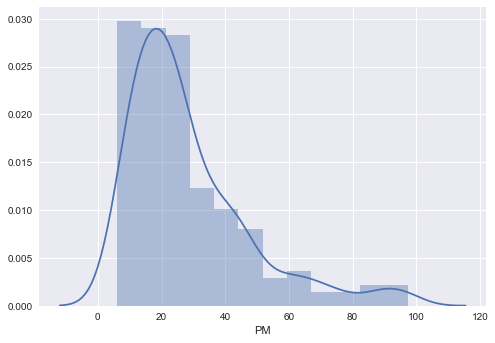

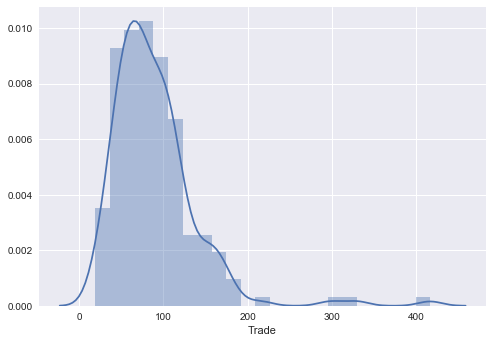

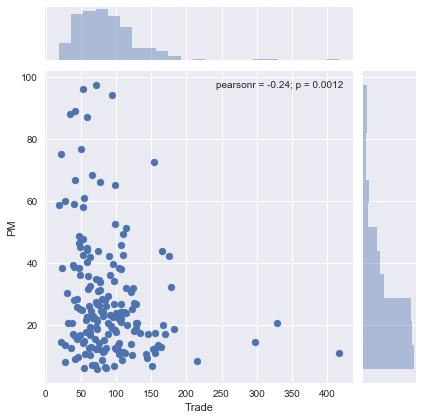

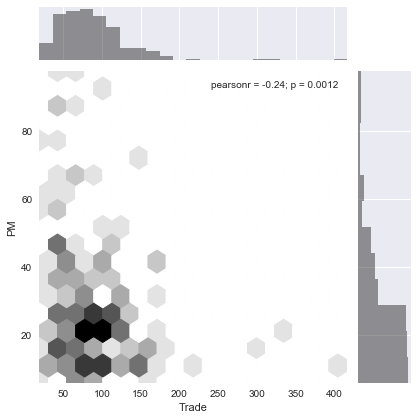

# Joint plots
Now create two different types of graphs that show the relationship between the two variables for a specific year. 

# Loops to create multiple graphs
In this cell we're going to graph each year's data in its own scatter plot, then save the file to our computer

<IPython.core.display.Javascript object>


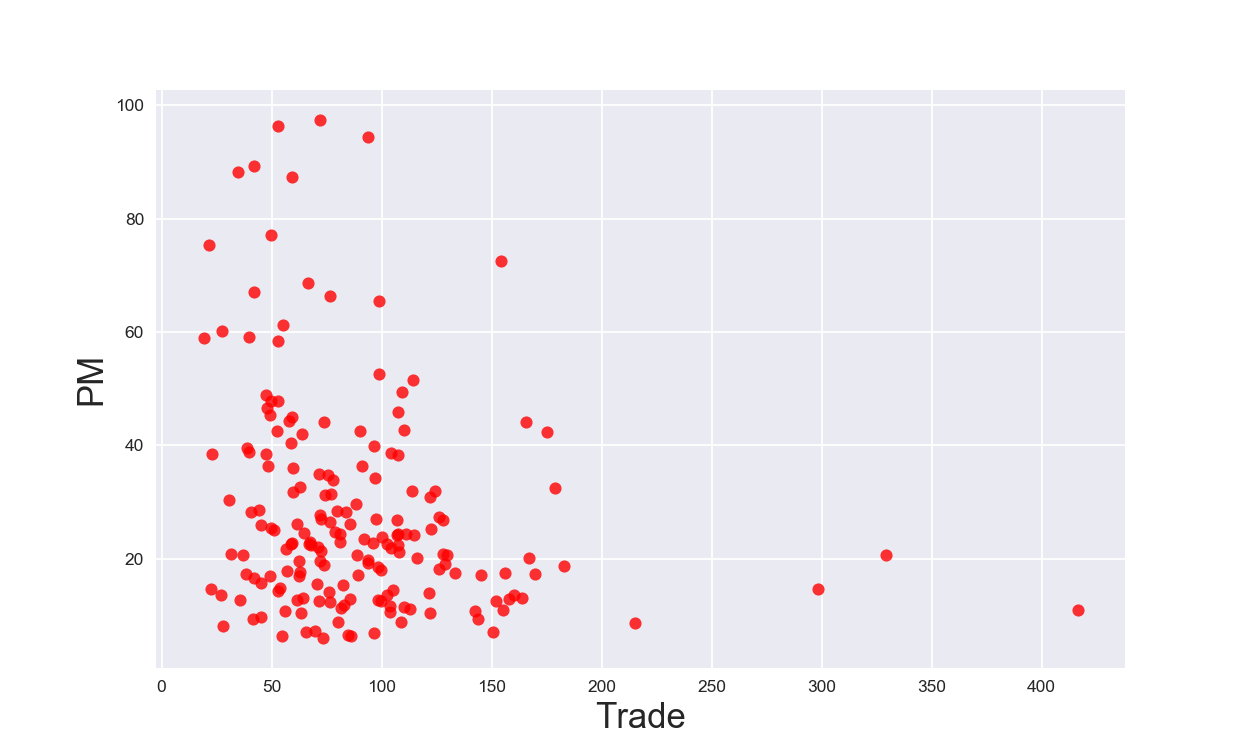

In [58]:
# Define the base graph
fig = plt.figure(figsize=(10,6))
plt.xlim(0, 700)
plt.ylim(0, 125)
plt.xlabel('International Trade as % of GDP',fontsize=20)
plt.ylabel('PM Concentration',fontsize=20)
plt.title('Trade and Pollution Across Countries',fontsize=20)

for i in range(2010,2017):
    df=pollution[pollution.Year==i]   #Pandas chaining creates a data subset for each year
    df.describe()
    image = sns.regplot(x=df.Trade, y=df.PM, color="b", fit_reg=False)
    graph_name='trade_pm'+str(i)+'.png'
    plt.savefig(graph_name)
    image.clear()

# Graph movies
In this cell we are going to create a movie that shows the evolution of trade and pollution together over time. Only complete this cell if you have time. 

<IPython.core.display.Javascript object>


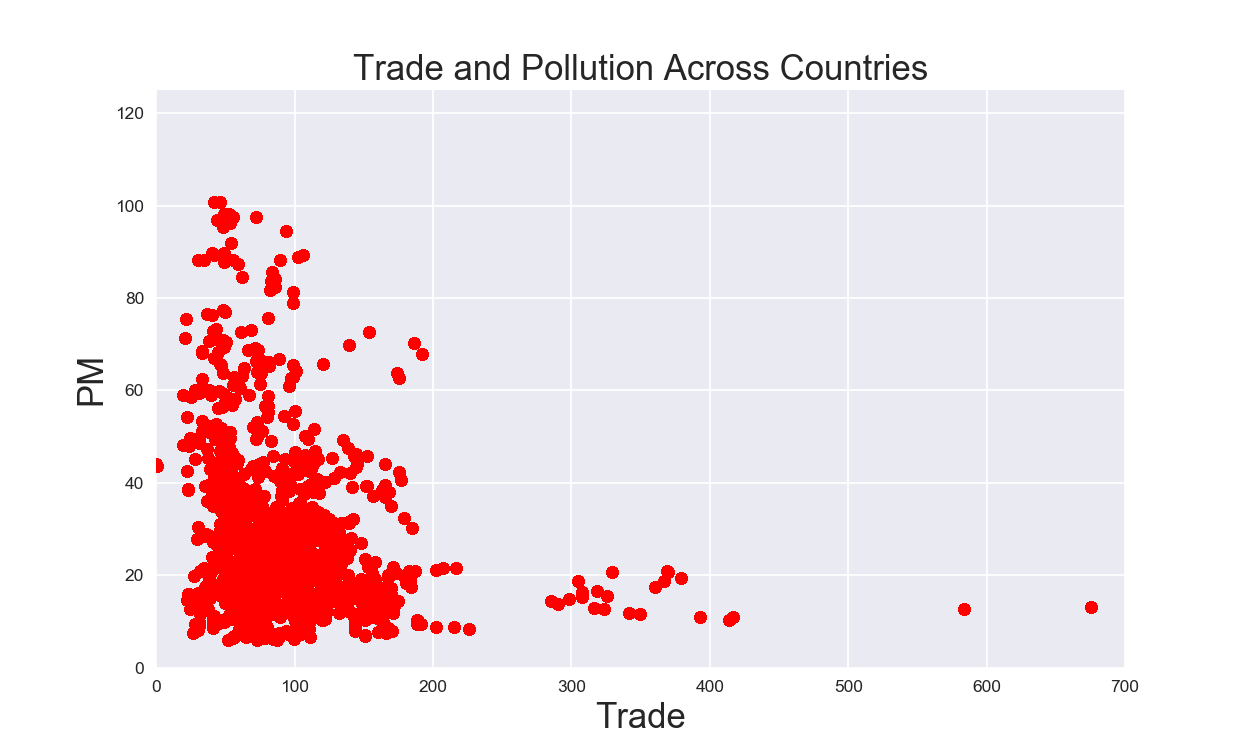

In [56]:
# Using  will let you see this image in the notebook, not just after it's saved
%matplotlib notebook
#Iniatilize the figure writer. Need to install a movie writer writer using the conda commmand prompt
Writer = animation.writers['ffmpeg'] 
writer = Writer(fps=2, metadata=dict(artist='Me'), bitrate=1800)

# Define the base graph
fig = plt.figure(figsize=(10,6))
plt.xlim(0, 700)
plt.ylim(0, 125)
plt.xlabel('International Trade as % of GDP',fontsize=20)
plt.ylabel('PM Concentration',fontsize=20)
plt.title('Trade and Pollution Across Countries',fontsize=20)

def animate(i):
    graph_year=i+2010
    image.clear()
    df=pollution[pollution.Year==(graph_year)]   #Pandas chaining creates a data subset for each year
    sns.regplot(x=df.Trade, y=df.PM, color="r", fit_reg=False)
    
ani = matplotlib.animation.FuncAnimation(fig, animate, frames=7, repeat=True)

df.describe()
ani.save('Scatter_Trade_Enviro.mp4', writer=writer)